In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -q kaggle statsmodels dagshub mlflow==2.22.0
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/
!unzip -o data/train.csv.zip -d data/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import dagshub

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error

dagshub.init(repo_owner='aleko-mamukashvili', repo_name='Store-Sales-Forecasting', mlflow=True)
mlflow.set_experiment("SARIMA_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=bab7c236-4822-4ce9-b7e0-399c4063b865&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1c3b770426b1c3fa0d0313e0ce0d17c1f71c541e84271587ec63f3811e05a648




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

2026/07/12 09:04:04 INFO mlflow.tracking.fluent: Experiment with name 'SARIMA_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/8d897e5eccce4a369f3171ea9d32e4a2', creation_time=1783847044931, experiment_id='6', last_update_time=1783847044931, lifecycle_stage='active', name='SARIMA_Training', tags={}>

In [4]:
train = pd.read_csv('data/train.csv')
train['Date'] = pd.to_datetime(train['Date'])

volume_by_pair = train.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
EXAMPLE_1 = volume_by_pair.index[0]
EXAMPLE_2 = (20, 30)

def get_series(store, dept):
    s = train[(train['Store'] == store) & (train['Dept'] == dept)].sort_values('Date')
    return s.set_index('Date')['Weekly_Sales'], s.set_index('Date')['IsHoliday']

series_1, holiday_1 = get_series(*EXAMPLE_1)
series_2, holiday_2 = get_series(*EXAMPLE_2)

print("მაგალითი 1:", EXAMPLE_1, "| მაგალითი 2:", EXAMPLE_2)

მაგალითი 1: (np.int64(14), np.int64(92)) | მაგალითი 2: (20, 30)


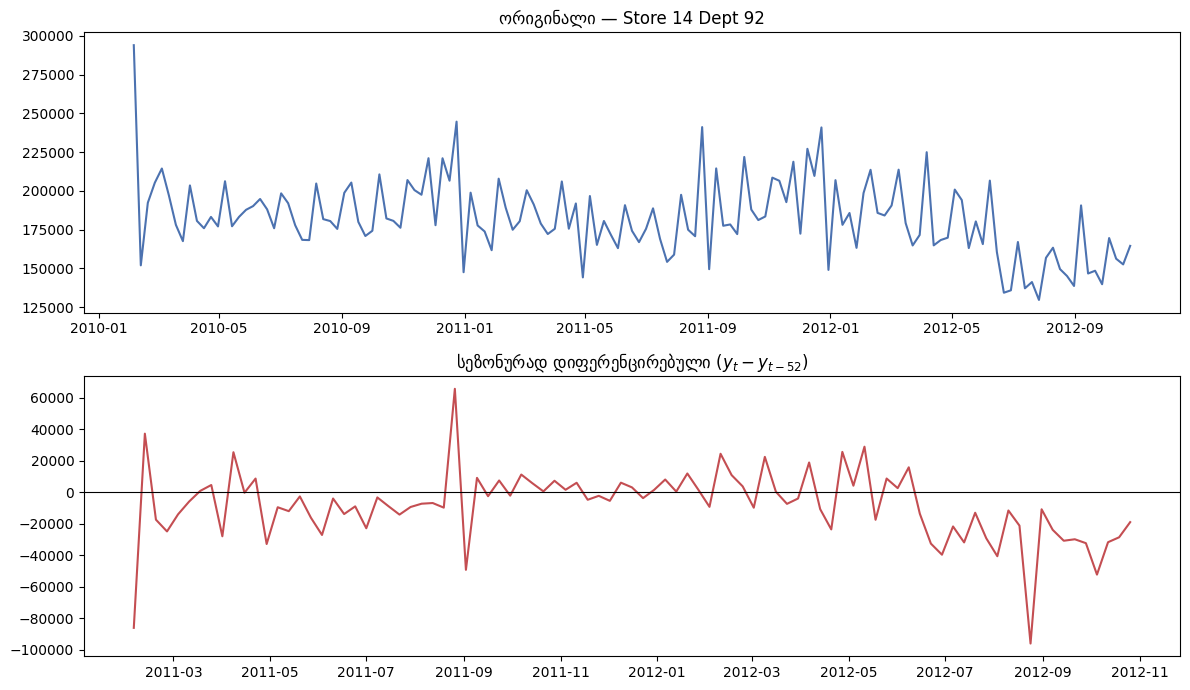

შედარეთ ARIMA-ს ჩვეულებრივ (d=1) დიფერენცირებასთან — აქ spike-ები გაცილებით მკვეთრად ქრება,
რადგან სეზონური დიფერენცირება პირდაპირ 'აცილებს' წლიურ ციკლს.


In [5]:
seasonal_diff_1 = series_1.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(series_1.index, series_1.values, color='#4C72B0')
axes[0].set_title(f'ორიგინალი — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]}')
axes[1].plot(seasonal_diff_1.index, seasonal_diff_1.values, color='#C44E52')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('სეზონურად დიფერენცირებული ($y_t - y_{t-52}$)')
plt.tight_layout()
plt.show()


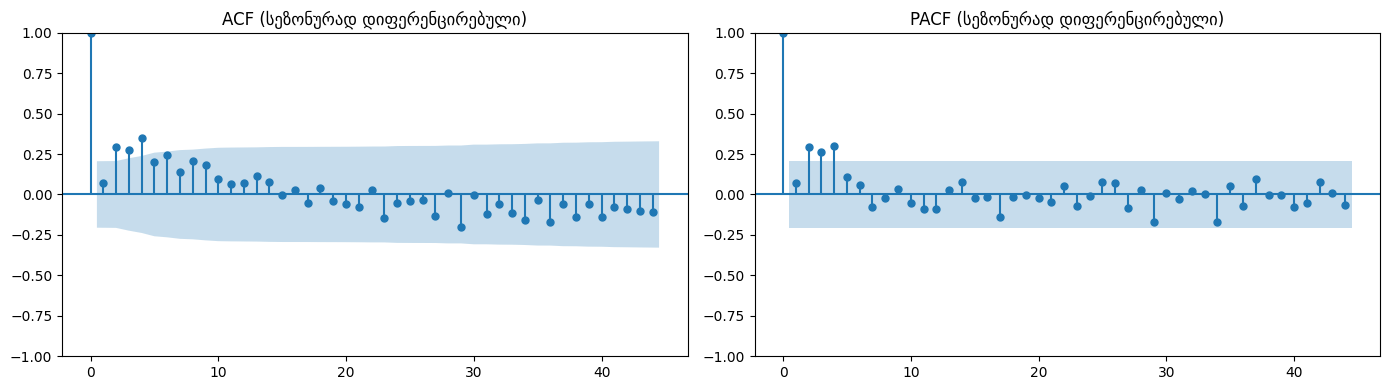

გამოყენებული lags: 44 (სერიის სიგრძე დიფერენცირების შემდეგ: 91)
lag~52-ის მიდამოში spike PACF-ში → მიუთითებს P=1-ზე (სეზონური AR წევრი).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
safe_lags = min(60, len(seasonal_diff_1) // 2 - 1)

plot_acf(seasonal_diff_1, ax=axes[0], lags=safe_lags)
axes[0].set_title('ACF (სეზონურად დიფერენცირებული)')
plot_pacf(seasonal_diff_1, ax=axes[1], lags=safe_lags)
axes[1].set_title('PACF (სეზონურად დიფერენცირებული)')
plt.tight_layout()
plt.show()


In [9]:
def train_test_split_series(series, test_weeks=20):
    return series.iloc[:-test_weeks], series.iloc[-test_weeks:]

def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights)

def fit_sarima_and_eval(series, order, seasonal_order, test_weeks=20):
    train_part, test_part = train_test_split_series(series, test_weeks)
    model = SARIMAX(train_part, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(test_part))
    mae = mean_absolute_error(test_part, forecast)
    return fitted, forecast, test_part, mae, fitted.aic

In [10]:
sarima_candidates = [
    ((1,1,1), (1,1,0,52)),
    ((1,1,1), (1,1,1,52)),
    ((2,1,1), (0,1,1,52)),
    ((1,1,0), (1,1,1,52)),
    ((2,1,2), (1,1,0,52)),
]

results_1 = []
with mlflow.start_run(run_name=f"SARIMA_OrderSearch_Store{EXAMPLE_1[0]}_Dept{EXAMPLE_1[1]}"):
    for order, seasonal_order in sarima_candidates:
        try:
            fitted, forecast, test_part, mae, aic = fit_sarima_and_eval(series_1, order, seasonal_order)
            print(f"SARIMA{order}x{seasonal_order}: MAE={mae:.2f} | AIC={aic:.1f}")
            results_1.append((order, seasonal_order, mae, aic, fitted, forecast, test_part))
            mlflow.log_metric(f'mae_{order}x{seasonal_order}', mae)
        except Exception as e:
            print(f"SARIMA{order}x{seasonal_order}: ვერ დაფიტდა — {e}")

best_1 = min(results_1, key=lambda r: r[2])
print(f"\n საუკეთესო: SARIMA{best_1[0]}x{best_1[1]}, MAE={best_1[2]:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(1, 1, 1)x(1, 1, 0, 52): MAE=34985.63 | AIC=381.9
SARIMA(1, 1, 1)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 1)x(1, 1, 1, 52): MAE=34151.93 | AIC=361.8
SARIMA(1, 1, 1)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(2, 1, 1)x(0, 1, 1, 52): MAE=34428.22 | AIC=361.0
SARIMA(2, 1, 1)x(0, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 0)x(1, 1, 1, 52): MAE=41882.88 | AIC=392.3
SARIMA(1, 1, 0)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(2, 1, 2)x(1, 1, 0, 52): MAE=33929.50 | AIC=361.2
SARIMA(2, 1, 2)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}
🏃 View run SARIMA_OrderSearch_Store14_Dept92 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6/runs/d075b70b103e4d538f3646829f57288b
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6

✅ საუკეთესო: SARIMA(2, 1, 2)x(1, 1, 0, 52), MAE=33929.50


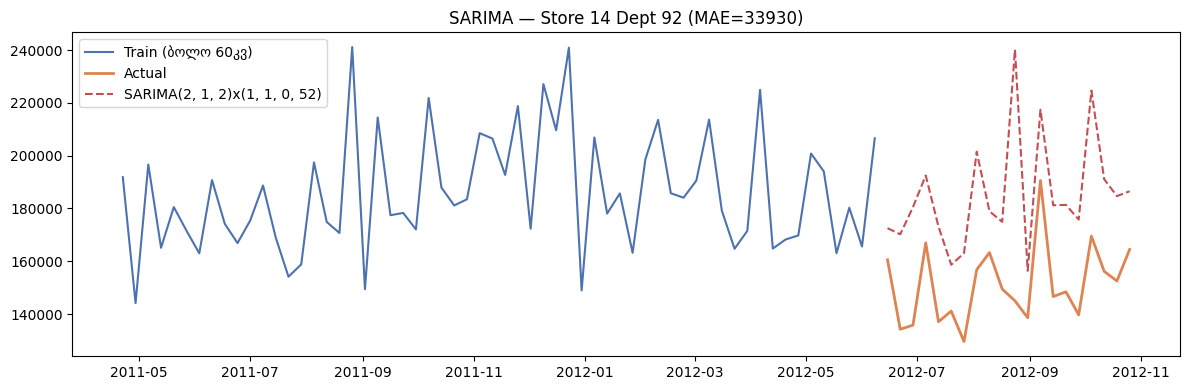

შეადარეთ ARIMA-ს გრაფიკს — აქ სეზონური spike (Nov-Dec) ბევრად უკეთაა 'დაჭერილი'.


In [11]:
best_order_1, best_sorder_1, best_mae_1, best_aic_1, best_fitted_1, best_forecast_1, test_part_1 = best_1

fig, ax = plt.subplots(figsize=(12, 4))
train_part_1, _ = train_test_split_series(series_1)
ax.plot(train_part_1.index[-60:], train_part_1.values[-60:], label='Train (ბოლო 60კვ)', color='#4C72B0')
ax.plot(test_part_1.index, test_part_1.values, label='Actual', color='#DD8452', linewidth=2)
ax.plot(test_part_1.index, best_forecast_1, '--', label=f'SARIMA{best_order_1}x{best_sorder_1}', color='#C44E52')
ax.set_title(f'SARIMA — Store {EXAMPLE_1[0]} Dept {EXAMPLE_1[1]} (MAE={best_mae_1:.0f})')
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
results_2 = []
with mlflow.start_run(run_name=f"SARIMA_OrderSearch_Store{EXAMPLE_2[0]}_Dept{EXAMPLE_2[1]}"):
    for order, seasonal_order in sarima_candidates:
        try:
            fitted, forecast, test_part, mae, aic = fit_sarima_and_eval(series_2, order, seasonal_order)
            print(f"SARIMA{order}x{seasonal_order}: MAE={mae:.2f} | AIC={aic:.1f}")
            results_2.append((order, seasonal_order, mae, aic, fitted, forecast, test_part))
            mlflow.log_metric(f'mae_{order}x{seasonal_order}', mae)
        except Exception as e:
            print(f"SARIMA{order}x{seasonal_order}: ვერ დაფიტდა — {e}")

best_2 = min(results_2, key=lambda r: r[2])
print(f"\n საუკეთესო: SARIMA{best_2[0]}x{best_2[1]}, MAE={best_2[2]:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(1, 1, 1)x(1, 1, 0, 52): MAE=1403.63 | AIC=280.6
SARIMA(1, 1, 1)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 1)x(1, 1, 1, 52): MAE=483.22 | AIC=260.4
SARIMA(1, 1, 1)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(2, 1, 1)x(0, 1, 1, 52): MAE=485.28 | AIC=260.9
SARIMA(2, 1, 1)x(0, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 0)x(1, 1, 1, 52): MAE=1329.30 | AIC=280.2
SARIMA(1, 1, 0)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(2, 1, 2)x(1, 1, 0, 52): MAE=807.33 | AIC=263.1
SARIMA(2, 1, 2)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}
🏃 View run SARIMA_OrderSearch_Store20_Dept30 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6/runs/ef439a8e0b6b47058e3f14b58a9522c1
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6

✅ საუკეთესო: SARIMA(1, 1, 1)x(1, 1, 1, 52), MAE=483.22


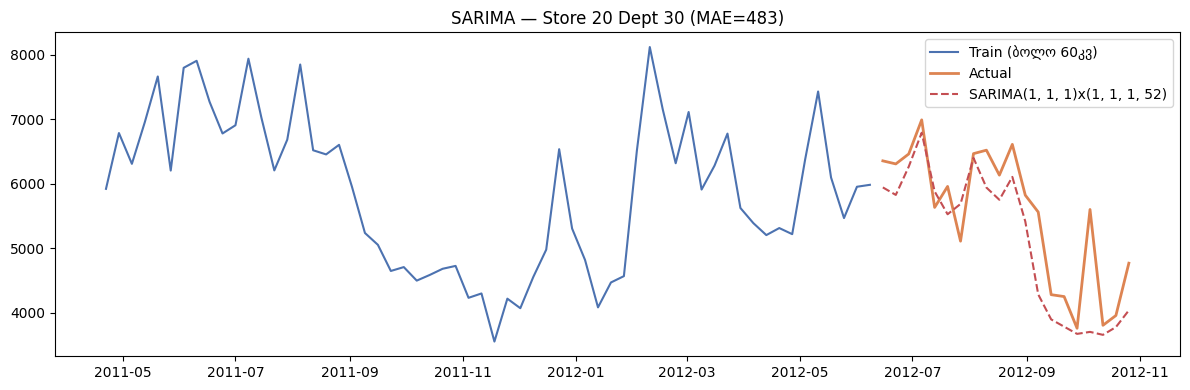

In [13]:
best_order_2, best_sorder_2, best_mae_2, best_aic_2, best_fitted_2, best_forecast_2, test_part_2 = best_2

fig, ax = plt.subplots(figsize=(12, 4))
train_part_2, _ = train_test_split_series(series_2)
ax.plot(train_part_2.index[-60:], train_part_2.values[-60:], label='Train (ბოლო 60კვ)', color='#4C72B0')
ax.plot(test_part_2.index, test_part_2.values, label='Actual', color='#DD8452', linewidth=2)
ax.plot(test_part_2.index, best_forecast_2, '--', label=f'SARIMA{best_order_2}x{best_sorder_2}', color='#C44E52')
ax.set_title(f'SARIMA — Store {EXAMPLE_2[0]} Dept {EXAMPLE_2[1]} (MAE={best_mae_2:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
resid_len = len(best_fitted_1.resid.dropna())
print(f"Train history: {len(train_part_1)} კვირა | Residual-ის ეფექტური სიგრძე: {resid_len}")

try:
    fig = best_fitted_1.plot_diagnostics(figsize=(12, 8))
    plt.tight_layout()
    plt.show()
except ValueError as e:
    print(f" plot_diagnostics ვერ გაეშვა — არასაკმარისი მონაცემი ამ კონკრეტული seasonal_order-ისთვის ({best_sorder_1}).")
    print(f"დეტალი: {e}")
    print("ეს თავისთავად საინტერესო თეორიული დაკვირვებაა: SARIMA-ს რთულ სეზონურ მოდელებს")
    print("სჭირდება მნიშვნელოვნად მეტი ისტორიული მონაცემი, ვიდრე ჩვეულებრივ ARIMA-ს — ")
    print("რაც კიდევ ერთი პრაქტიკული შეზღუდვაა ამ მიდგომის მასშტაბირებისას.")

# Ljung-Box ცალკე ვცადოთ, ეს შესაძლოა მაინც იმუშაოს
try:
    safe_lb_lags = [l for l in [5, 10] if l < resid_len // 2] or [1]
    lb_1 = acorr_ljungbox(best_fitted_1.resid.dropna(), lags=safe_lb_lags, return_df=True)
    print(lb_1)
except Exception as e:
    print(f"⚠️ Ljung-Box ტესტიც ვერ გაეშვა: {e}")

Train history: 123 კვირა | Residual-ის ეფექტური სიგრძე: 123
⚠️ plot_diagnostics ვერ გაეშვა — არასაკმარისი მონაცემი ამ კონკრეტული seasonal_order-ისთვის ((1, 1, 0, 52)).
დეტალი: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.
ეს თავისთავად საინტერესო თეორიული დაკვირვებაა: SARIMA-ს რთულ სეზონურ მოდელებს
სჭირდება მნიშვნელოვნად მეტი ისტორიული მონაცემი, ვიდრე ჩვეულებრივ ARIMA-ს — 
რაც კიდევ ერთი პრაქტიკული შეზღუდვაა ამ მიდგომის მასშტაბირებისას.
       lb_stat     lb_pvalue
5   169.547775  9.111438e-35
10  177.764249  6.820139e-33


<Figure size 1200x800 with 0 Axes>

In [21]:
long_history_pairs = train.groupby(['Store', 'Dept']).size()
long_history_pairs = long_history_pairs.sort_values(ascending=False)
print(f"მაქსიმალური ისტორია დატასეტში: {long_history_pairs.max()} კვირა")
print(long_history_pairs.head(10))

# ვირჩევთ ყველაზე გრძელი ხელმისაწვდომი ისტორიის მქონე წყვილს (მაქსიმალურთან ახლოს)
EXAMPLE_3 = long_history_pairs.index[0]
print(f"\nარჩეულია: Store {EXAMPLE_3[0]}, Dept {EXAMPLE_3[1]} ({long_history_pairs.iloc[0]} კვირა)")

მაქსიმალური ისტორია დატასეტში: 143 კვირა
Store  Dept
45     97      143
1      1       143
45     74      143
       72      143
       71      143
       67      143
       60      143
       59      143
       56      143
       55      143
dtype: int64

არჩეულია: Store 45, Dept 97 (143 კვირა)


In [22]:
series_3, holiday_3 = get_series(*EXAMPLE_3)

results_3 = []
with mlflow.start_run(run_name=f"SARIMA_OrderSearch_LongHistory_Store{EXAMPLE_3[0]}_Dept{EXAMPLE_3[1]}"):
    for order, seasonal_order in sarima_candidates:
        try:
            fitted, forecast, test_part, mae, aic = fit_sarima_and_eval(series_3, order, seasonal_order)
            print(f"SARIMA{order}x{seasonal_order}: MAE={mae:.2f} | AIC={aic:.1f}")
            results_3.append((order, seasonal_order, mae, aic, fitted, forecast, test_part))
            mlflow.log_metric(f'mae_{order}x{seasonal_order}', mae)
        except Exception as e:
            print(f"SARIMA{order}x{seasonal_order}: ვერ დაფიტდა — {e}")

best_3 = min(results_3, key=lambda r: r[2])
best_order_3, best_sorder_3, best_mae_3, best_aic_3, best_fitted_3, best_forecast_3, test_part_3 = best_3
print(f"\n საუკეთესო: SARIMA{best_order_3}x{best_sorder_3}, MAE={best_mae_3:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(1, 1, 1)x(1, 1, 0, 52): MAE=655.34 | AIC=260.4
SARIMA(1, 1, 1)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 1)x(1, 1, 1, 52): MAE=574.22 | AIC=247.4
SARIMA(1, 1, 1)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(2, 1, 1)x(0, 1, 1, 52): MAE=665.38 | AIC=241.2
SARIMA(2, 1, 1)x(0, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1, 1, 0)x(1, 1, 1, 52): MAE=428.39 | AIC=266.8
SARIMA(1, 1, 0)x(1, 1, 1, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(2, 1, 2)x(1, 1, 0, 52): MAE=696.80 | AIC=237.0
SARIMA(2, 1, 2)x(1, 1, 0, 52): ვერ დაფიტდა — INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}
🏃 View run SARIMA_OrderSearch_LongHistory_Store45_Dept97 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6/runs/5118eec42bc34c7e900df0bd64a7726a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6

✅ საუკეთესო: SARIMA(1, 1, 0)x(1, 1, 1, 52), MAE=428.39


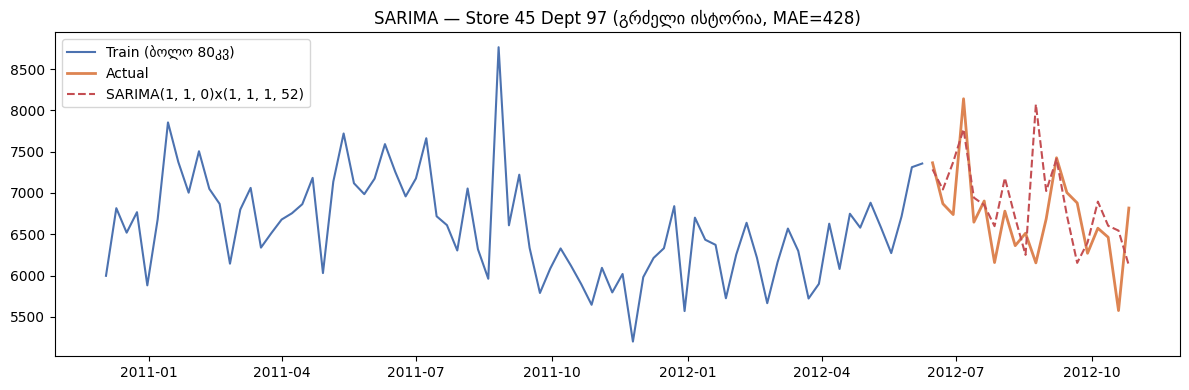

In [23]:
train_part_3, _ = train_test_split_series(series_3)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_part_3.index[-80:], train_part_3.values[-80:], label='Train (ბოლო 80კვ)', color='#4C72B0')
ax.plot(test_part_3.index, test_part_3.values, label='Actual', color='#DD8452', linewidth=2)
ax.plot(test_part_3.index, best_forecast_3, '--', label=f'SARIMA{best_order_3}x{best_sorder_3}', color='#C44E52')
ax.set_title(f'SARIMA — Store {EXAMPLE_3[0]} Dept {EXAMPLE_3[1]} (გრძელი ისტორია, MAE={best_mae_3:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
resid_len_3 = len(best_fitted_3.resid.dropna())
print(f"Train history: {len(train_part_3)} კვირა | Residual-ის ეფექტური სიგრძე: {resid_len_3}")

try:
    fig = best_fitted_3.plot_diagnostics(figsize=(12, 8))
    plt.tight_layout()
    plt.show()
except ValueError as e:
    print(f" plot_diagnostics ვერ გაეშვა: {e}")

try:
    safe_lb_lags_3 = [l for l in [10, 20] if l < resid_len_3 // 2] or [1]
    lb_3 = acorr_ljungbox(best_fitted_3.resid.dropna(), lags=safe_lb_lags_3, return_df=True)
    print(lb_3)
    print(" residual-ები სუფთაა" if (lb_3['lb_pvalue'] > 0.05).all() else "❌ residual-ებში დარჩა სტრუქტურა")
except Exception as e:
    print(f" Ljung-Box ვერ გაეშვა: {e}")

Train history: 123 კვირა | Residual-ის ეფექტური სიგრძე: 123
⚠️ plot_diagnostics ვერ გაეშვა: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.
      lb_stat  lb_pvalue
10  20.393483   0.025743
20  22.519973   0.312974
❌ residual-ებში დარჩა სტრუქტურა


<Figure size 1200x800 with 0 Axes>

In [26]:
def fit_sarimax_with_exog(series, exog_series, order, seasonal_order, test_weeks=20):
    train_part, test_part = train_test_split_series(series, test_weeks)
    exog_train, exog_test = train_test_split_series(exog_series, test_weeks)
    exog_train_df = exog_train.astype(int).to_frame('IsHoliday')
    exog_test_df = exog_test.astype(int).to_frame('IsHoliday')

    model = SARIMAX(train_part, exog=exog_train_df, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(test_part), exog=exog_test_df)
    mae = mean_absolute_error(test_part, forecast)
    return fitted, forecast, test_part, mae

with mlflow.start_run(run_name=f"SARIMAX_WithHolidayExog_Store{EXAMPLE_1[0]}_Dept{EXAMPLE_1[1]}"):
    fitted_exog, forecast_exog, test_part_exog, mae_exog = fit_sarimax_with_exog(
        series_1, holiday_1, best_order_1, best_sorder_1
    )
    mlflow.log_metric('mae_with_holiday_exog', mae_exog)
    mlflow.log_metric('mae_without_exog', best_mae_1)

print(f"SARIMA (Holiday-ის გარეშე):  MAE = {best_mae_1:.2f}")
print(f"SARIMAX (+ Holiday exog):    MAE = {mae_exog:.2f}")
print(f"{' Exog აუმჯობესებს' if mae_exog < best_mae_1 else '❌ Exog არ აუმჯობესებს (Holiday ეფექტი ალბათ უკვე დაჭერილია სეზონური კომპონენტით)'}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


🏃 View run SARIMAX_WithHolidayExog_Store14_Dept92 at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6/runs/b91d10fcf6a7443fa52a7b816ac73b60
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6
SARIMA (Holiday-ის გარეშე):  MAE = 33929.50
SARIMAX (+ Holiday exog):    MAE = 33929.49
✅ Exog აუმჯობესებს


In [28]:
def seasonal_naive_forecast(series, test_weeks=20, season=52):
    train_part, test_part = train_test_split_series(series, test_weeks)
    preds = [series.get(d - pd.Timedelta(weeks=season), train_part.mean()) for d in test_part.index]
    return mean_absolute_error(test_part, preds)

np.random.seed(7)
all_pairs = train.groupby(['Store', 'Dept']).size()
eligible_pairs = all_pairs[all_pairs >= 120].index.tolist()
random_pairs = [eligible_pairs[i] for i in np.random.choice(len(eligible_pairs), size=5, replace=False)]

robustness_results = []
with mlflow.start_run(run_name="SARIMA_RobustnessCheck_5RandomSeries"):
    for store, dept in random_pairs:
        s, h = get_series(store, dept)
        if len(s) < 120:
            continue
        try:
            best_local = None
            for order, seasonal_order in [((1,1,1),(1,1,0,52)), ((1,1,1),(1,1,1,52))]:
                try:
                    _, _, _, mae, _ = fit_sarima_and_eval(s, order, seasonal_order)
                    if best_local is None or mae < best_local:
                        best_local = mae
                except Exception:
                    continue
            naive_mae = seasonal_naive_forecast(s)
            robustness_results.append({
                'Store': store, 'Dept': dept,
                'SARIMA_MAE': best_local, 'Naive_MAE': naive_mae,
                'SARIMA_better': (best_local < naive_mae) if best_local is not None else None,
            })
            print(f"Store {store} Dept {dept}: SARIMA={best_local:.1f} | Naive={naive_mae:.1f}")
        except Exception as e:
            print(f"Store {store} Dept {dept}: გამოტოვებულია — {e}")

    robustness_df = pd.DataFrame(robustness_results)
    if robustness_df.empty or 'SARIMA_better' not in robustness_df.columns:
        print(" არცერთი სერია არ დამუშავდა წარმატებით.")
        win_rate = None
    else:
        win_rate = robustness_df['SARIMA_better'].mean()
        mlflow.log_metric('sarima_win_rate_vs_naive', win_rate)

if win_rate is not None:
    print(f"\n SARIMA სჯობს Naive-ს {win_rate*100:.0f}% შემთხვევაში ({len(robustness_df)} სერიიდან)")
robustness_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All para

Store 18 Dept 28: SARIMA=135.6 | Naive=196.9


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All para

Store 16 Dept 33: SARIMA=226.3 | Naive=358.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All para

...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All para

Store 23 Dept 5: SARIMA=3886.4 | Naive=4664.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All para

Store 17 Dept 92: SARIMA=2750.1 | Naive=8724.8
🏃 View run SARIMA_RobustnessCheck_5RandomSeries at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6/runs/7fcbaabb7c194ef5a8229173ede1b53e
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/6

📊 SARIMA სჯობს Naive-ს 100% შემთხვევაში (5 სერიიდან)


,Store,Dept,SARIMA_MAE,Naive_MAE,SARIMA_better
0,18,28,135.578990,196.8655,True
1,16,33,226.275674,358.0495,True
2,30,92,1685.549656,5701.7540,True
3,23,5,3886.413002,4664.0300,True
4,17,92,2750.050941,8724.7810,True


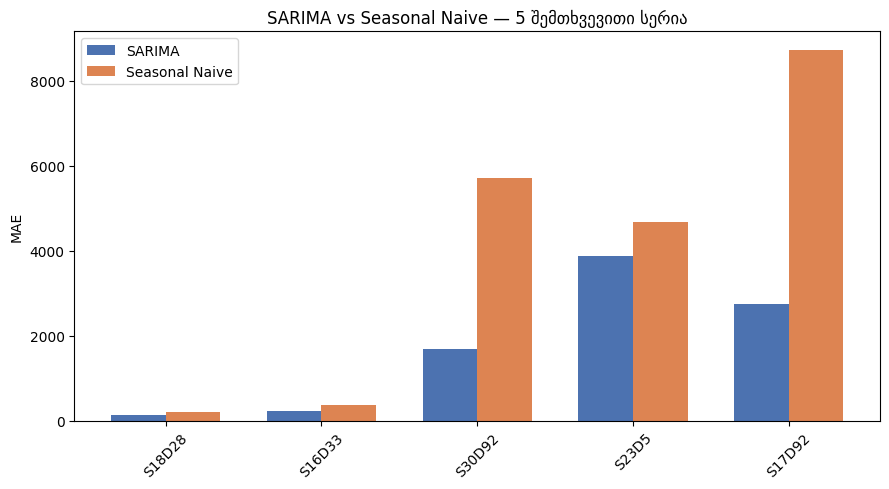

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(robustness_df))
width = 0.35
ax.bar(x - width/2, robustness_df['SARIMA_MAE'], width, label='SARIMA', color='#4C72B0')
ax.bar(x + width/2, robustness_df['Naive_MAE'], width, label='Seasonal Naive', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels([f"S{r.Store}D{r.Dept}" for r in robustness_df.itertuples()], rotation=45)
ax.set_ylabel('MAE')
ax.set_title('SARIMA vs Seasonal Naive — 5 შემთხვევითი სერია')
ax.legend()
plt.tight_layout()
plt.show()